In [1]:
from pathlib import Path
from PIL import Image
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    CLIPModel,
    CLIPProcessor,
    BlipModel,
    AutoProcessor,
)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

img_clean_path = Path("data/clean_girl_01.jpeg")
img_medieval_path = Path("data/medieval_baths_01.jpeg")

Device: cpu


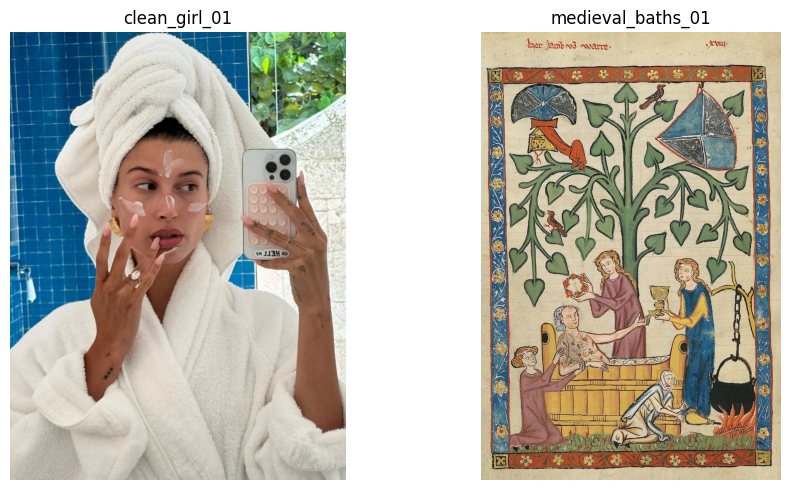

In [4]:
img_clean = Image.open("/Users/shannon/Desktop/workspace_msh/multimodal-metric-survey/data/img_clean/clean_girl_03.jpeg").convert("RGB")
img_medieval = Image.open("/Users/shannon/Desktop/workspace_msh/multimodal-metric-survey/data/img_medieval/medieval_baths_01.jpeg").convert("RGB")

fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(img_clean)
ax1.set_title("clean_girl_01")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(img_medieval)
ax2.set_title("medieval_baths_01")
ax2.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Some example prompts for the "bath" category. These prompts can be used to evaluate how well the model captures the concept of "clean" in different contexts.
texts_bath = [
    "a clean hygienic bathing space",
    "a very clean sanitary environment",
    "a space for washing and purification",
    "a dirty unhealthy place",
    "a place associated with disease",
    "a smelly and unpleasant place",
    "a beauty and self-care routine",
    "an everything shower routine",
    "a clean girl aesthetic routine",
    "a minimalist and ascetic self-care ritual",
    "a place for the poor with limited hygiene",
    "a space used by people in need",
]

texts_bath_dirty = [
    "a dirty unhealthy place",
    "a place associated with disease",
    "an unsanitary bathing environment",
    "a smelly and unpleasant place"
]

texts_bath_dirty = [
    "a dirty unhealthy place",
    "a place associated with disease",
    "an unsanitary bathing environment",
    "a smelly and unpleasant place"
]

texts_bath_beauty = [
    "a beauty and self-care routine",
    "a place for body care and grooming",
    "a luxurious bathing ritual",
    "an everything shower routine",
    "a clean girl aesthetic routine",
    "a minimalist and ascetic self-care ritual"
]

texts_bath_intimacy = [
    "an intimate bathing scene",
    "a sensual moment in the bath",
    "a romantic bathing atmosphere",
    "a private moment of care"
]

# To structure more categories, we can create a dictionary of prompt sets. Each key is a category name, and the value is a list of prompts related to that category. For example:
prompt_sets = {
    "bath_probe_v1": texts_bath,
    "bath_probe_v2": texts_bath_dirty,
    "bath_probe_v3": texts_bath_beauty,
    "bath_probe_v4": texts_bath_intimacy,
}

active_texts = prompt_sets["bath_probe_v1"]
print(f"{len(active_texts)} prompts loaded")

prompt_sets

12 prompts loaded


{'bath_probe_v1': ['a clean hygienic bathing space',
  'a very clean sanitary environment',
  'a space for washing and purification',
  'a dirty unhealthy place',
  'a place associated with disease',
  'a smelly and unpleasant place',
  'a beauty and self-care routine',
  'an everything shower routine',
  'a clean girl aesthetic routine',
  'a minimalist and ascetic self-care ritual',
  'a place for the poor with limited hygiene',
  'a space used by people in need'],
 'bath_probe_v2': ['a dirty unhealthy place',
  'a place associated with disease',
  'an unsanitary bathing environment',
  'a smelly and unpleasant place'],
 'bath_probe_v3': ['a beauty and self-care routine',
  'a place for body care and grooming',
  'a luxurious bathing ritual',
  'an everything shower routine',
  'a clean girl aesthetic routine',
  'a minimalist and ascetic self-care ritual'],
 'bath_probe_v4': ['an intimate bathing scene',
  'a sensual moment in the bath',
  'a romantic bathing atmosphere',
  'a priva

In [9]:
clip_model_name = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_model.eval()

print("CLIP loaded")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded


In [10]:
def compute_clip_scores(image, texts, model, processor, device="cpu"):
    inputs = processor(
        text=texts,
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        scores = (image_embeds @ text_embeds.T).squeeze(0).cpu().numpy()

    return scores

In [11]:
clip_scores_clean = compute_clip_scores(
    img_clean, active_texts, clip_model, clip_processor, device=device
)

clip_scores_medieval = compute_clip_scores(
    img_medieval, active_texts, clip_model, clip_processor, device=device
)

df_clip = pd.DataFrame({
    "text": active_texts,
    "clip_clean_girl_01": clip_scores_clean,
    "clip_medieval_baths_01": clip_scores_medieval,
})

df_clip["clip_diff_clean_minus_medieval"] = (
    df_clip["clip_clean_girl_01"] - df_clip["clip_medieval_baths_01"]
)

df_clip.sort_values("clip_diff_clean_minus_medieval", ascending=False)

,text,clip_clean_girl_01,clip_medieval_baths_01,clip_diff_clean_minus_medieval
8,a clean girl aesthetic routine,0.270217,0.177333,0.092884
6,a beauty and self-care routine,0.289112,0.210653,0.078459
7,an everything shower routine,0.279107,0.202026,0.077082
9,a minimalist and ascetic self-care ritual,0.270751,0.221376,0.049375
3,a dirty unhealthy place,0.214080,0.182305,0.031776
0,a clean hygienic bathing space,0.230401,0.228957,0.001445
1,a very clean sanitary environment,0.207640,0.208587,-0.000948
10,a place for the poor with limited hygiene,0.211653,0.218940,-0.007287
5,a smelly and unpleasant place,0.188671,0.212146,-0.023475
4,a place associated with disease,0.186251,0.226788,-0.040537


<Figure size 1200x600 with 0 Axes>

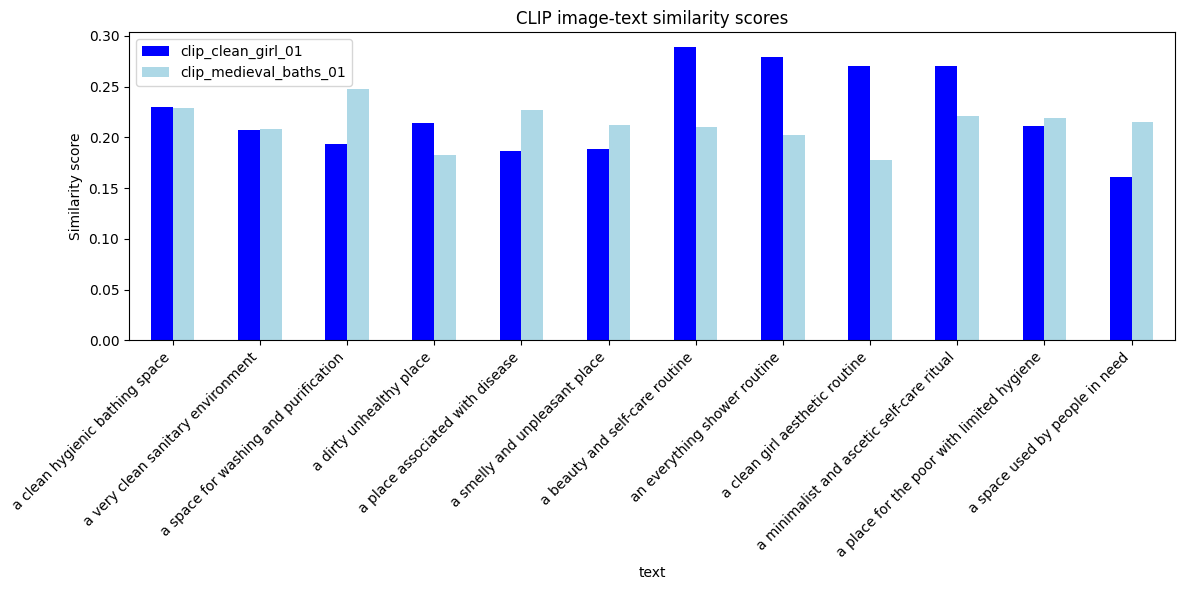

In [14]:
plot_df = df_clip.set_index("text")[["clip_clean_girl_01", "clip_medieval_baths_01"]]

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", figsize=(12, 6), color=["blue", "lightblue"])
plt.title("CLIP image-text similarity scores")
plt.ylabel("Similarity score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
blip_model_name = "Salesforce/blip-itm-base-coco"

blip_processor = AutoProcessor.from_pretrained(blip_model_name)
blip_model = BlipModel.from_pretrained(blip_model_name).to(device)
blip_model.eval()

print("BLIP loaded")

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

`BlipModel` is going to be deprecated in future release, please use `BlipForConditionalGeneration`, `BlipForQuestionAnswering` or `BlipForImageTextRetrieval` depending on your usecase.


Loading weights:   0%|          | 0/150 [00:00<?, ?it/s]

BlipModel LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                                                        | Status     | 
---------------------------------------------------------------------------+------------+-
text_encoder.encoder.layer.{0...11}.crossattention.self.query.bias         | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.crossattention.self.value.weight       | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.output.dense.weight                    | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.attention.self.value.weight            | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.crossattention.output.LayerNorm.weight | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.intermediate.dense.weight              | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.attention.self.value.bias              | UNEXPECTED | 
text_encoder.encoder.layer.{0...11}.attention.output.dense.weight          | UNEXPECTED | 
text_encoder.encoder.layer.{0...

BLIP loaded


model.safetensors:   0%|          | 0.00/895M [00:00<?, ?B/s]

In [21]:
def compute_blip_scores(image, texts, model, processor, device="cpu"):
    inputs = processor(
        images=image,
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        image_output = model.get_image_features(pixel_values=inputs["pixel_values"])
        text_output = model.get_text_features(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        # unwrap model outputs into tensors
        if hasattr(image_output, "pooler_output") and image_output.pooler_output is not None:
            image_features = image_output.pooler_output
        elif hasattr(image_output, "last_hidden_state") and image_output.last_hidden_state is not None:
            image_features = image_output.last_hidden_state[:, 0, :]
        else:
            image_features = image_output

        if hasattr(text_output, "pooler_output") and text_output.pooler_output is not None:
            text_features = text_output.pooler_output
        elif hasattr(text_output, "last_hidden_state") and text_output.last_hidden_state is not None:
            text_features = text_output.last_hidden_state[:, 0, :]
        else:
            text_features = text_output

        # safety check
        if not isinstance(image_features, torch.Tensor):
            raise TypeError(f"image_features is not a tensor: {type(image_features)}")
        if not isinstance(text_features, torch.Tensor):
            raise TypeError(f"text_features is not a tensor: {type(text_features)}")

        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        scores = (image_features @ text_features.T).squeeze(0).cpu().numpy()

    return scores

In [22]:
blip_scores_clean = compute_blip_scores(
    img_clean, active_texts, blip_model, blip_processor, device=device
)

blip_scores_medieval = compute_blip_scores(
    img_medieval, active_texts, blip_model, blip_processor, device=device
)

df_blip = pd.DataFrame({
    "text": active_texts,
    "blip_clean_girl_01": blip_scores_clean,
    "blip_medieval_baths_01": blip_scores_medieval,
})

df_blip["blip_diff_clean_minus_medieval"] = (
    df_blip["blip_clean_girl_01"] - df_blip["blip_medieval_baths_01"]
)

df_blip.sort_values("blip_diff_clean_minus_medieval", ascending=False)

,text,blip_clean_girl_01,blip_medieval_baths_01,blip_diff_clean_minus_medieval
10,a place for the poor with limited hygiene,0.038040,-0.014996,0.053035
7,an everything shower routine,0.045339,-0.002243,0.047582
4,a place associated with disease,0.022440,-0.024960,0.047400
3,a dirty unhealthy place,0.031889,-0.015454,0.047343
6,a beauty and self-care routine,0.033281,-0.013336,0.046618
2,a space for washing and purification,0.032164,-0.013149,0.045313
5,a smelly and unpleasant place,0.041994,0.001431,0.040563
0,a clean hygienic bathing space,0.007419,-0.029113,0.036531
9,a minimalist and ascetic self-care ritual,0.009402,-0.021069,0.030471
1,a very clean sanitary environment,0.017603,-0.005618,0.023221


<Figure size 1200x600 with 0 Axes>

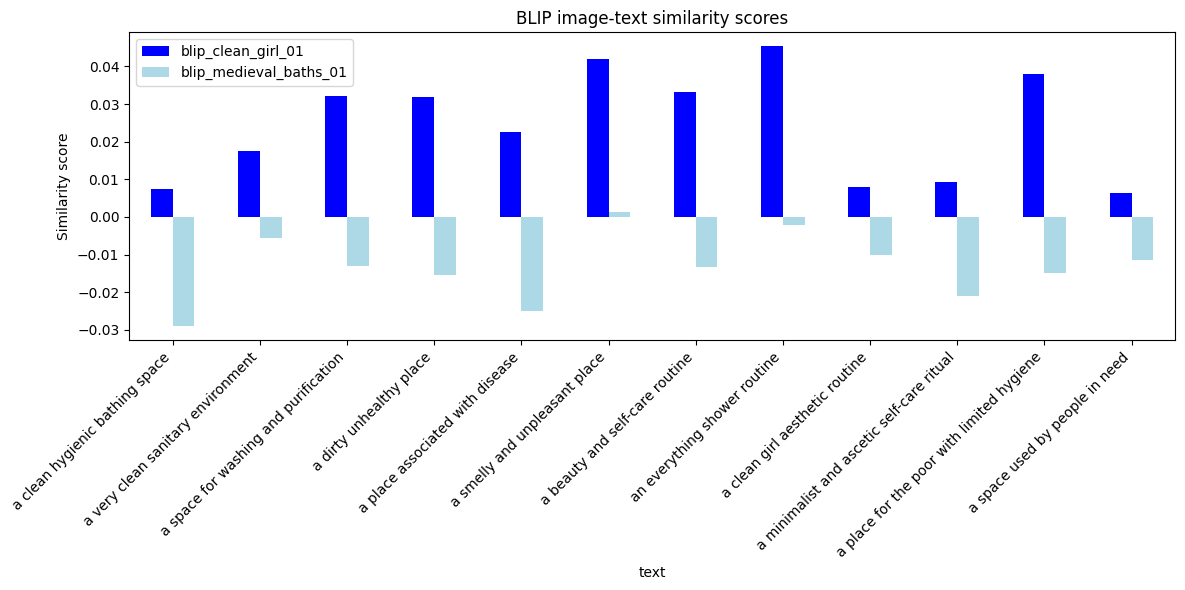

In [28]:
plot_df_blip = df_blip.set_index("text")[["blip_clean_girl_01", "blip_medieval_baths_01"]]

plt.figure(figsize=(12, 6))
plot_df_blip.plot(kind="bar", figsize=(12, 6), color=("blue", "lightblue"))
plt.title("BLIP image-text similarity scores")
plt.ylabel("Similarity score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
df_all = df_clip.merge(df_blip, on="text")
df_all

,text,clip_clean_girl_01,clip_medieval_baths_01,clip_diff_clean_minus_medieval,blip_clean_girl_01,blip_medieval_baths_01,blip_diff_clean_minus_medieval
0,a clean hygienic bathing space,0.230401,0.228957,0.001445,0.007419,-0.029113,0.036531
1,a very clean sanitary environment,0.207640,0.208587,-0.000948,0.017603,-0.005618,0.023221
2,a space for washing and purification,0.193726,0.248050,-0.054323,0.032164,-0.013149,0.045313
3,a dirty unhealthy place,0.214080,0.182305,0.031776,0.031889,-0.015454,0.047343
4,a place associated with disease,0.186251,0.226788,-0.040537,0.022440,-0.024960,0.047400
5,a smelly and unpleasant place,0.188671,0.212146,-0.023475,0.041994,0.001431,0.040563
6,a beauty and self-care routine,0.289112,0.210653,0.078459,0.033281,-0.013336,0.046618
7,an everything shower routine,0.279107,0.202026,0.077082,0.045339,-0.002243,0.047582
8,a clean girl aesthetic routine,0.270217,0.177333,0.092884,0.007952,-0.010010,0.017962
9,a minimalist and ascetic self-care ritual,0.270751,0.221376,0.049375,0.009402,-0.021069,0.030471


In [30]:
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

df_all.to_csv(results_dir / "bath_probe_two_images_clip_blip.csv", index=False)
print("Saved:", results_dir / "bath_probe_two_images_clip_blip.csv")

Saved: results/bath_probe_two_images_clip_blip.csv


In [31]:
display(df_all.sort_values("clip_diff_clean_minus_medieval", ascending=False).head(5))
display(df_all.sort_values("clip_diff_clean_minus_medieval", ascending=True).head(5))

,text,clip_clean_girl_01,clip_medieval_baths_01,clip_diff_clean_minus_medieval,blip_clean_girl_01,blip_medieval_baths_01,blip_diff_clean_minus_medieval
8,a clean girl aesthetic routine,0.270217,0.177333,0.092884,0.007952,-0.010010,0.017962
6,a beauty and self-care routine,0.289112,0.210653,0.078459,0.033281,-0.013336,0.046618
7,an everything shower routine,0.279107,0.202026,0.077082,0.045339,-0.002243,0.047582
9,a minimalist and ascetic self-care ritual,0.270751,0.221376,0.049375,0.009402,-0.021069,0.030471
3,a dirty unhealthy place,0.214080,0.182305,0.031776,0.031889,-0.015454,0.047343


,text,clip_clean_girl_01,clip_medieval_baths_01,clip_diff_clean_minus_medieval,blip_clean_girl_01,blip_medieval_baths_01,blip_diff_clean_minus_medieval
2,a space for washing and purification,0.193726,0.248050,-0.054323,0.032164,-0.013149,0.045313
11,a space used by people in need,0.161346,0.215601,-0.054255,0.006244,-0.011400,0.017644
4,a place associated with disease,0.186251,0.226788,-0.040537,0.022440,-0.024960,0.047400
5,a smelly and unpleasant place,0.188671,0.212146,-0.023475,0.041994,0.001431,0.040563
10,a place for the poor with limited hygiene,0.211653,0.218940,-0.007287,0.038040,-0.014996,0.053035
